## **Langchain Agent *Intro*** 

In [21]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [42]:
from pydantic import BaseModel

class WeatherOutput(BaseModel):
    temperature: float
    description: str

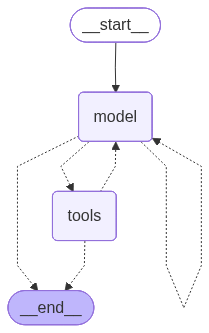

In [49]:
from langchain.agents import create_agent
from langchain.tools import tool
from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen/qwen3-32b")   

@tool
def get_weather(location: str) -> str:
    """A mock function to get weather information for a given location."""
    return f"The weather in {location} is sunny with a high of 25°C."

agent = create_agent(
    name = "WeatherAgent",
    model = llm,
    tools = [get_weather],
    system_prompt = "You are a helpful assistant. You can use the get_weather function to provide weather information for any location.",
    response_format = WeatherOutput,
)
agent 

In [44]:
response = agent.invoke({"message":[{"role": "user", "content": "What is the weather in New York?"}]})

In [47]:
response["messages"][-1].content

"Returning structured response: temperature=25.0 description='sunny'"

In [48]:
response["structured_response"]

WeatherOutput(temperature=25.0, description='sunny')

## **Depp Dive into the topics** : `Agents, Tools, Models, Messages, Memory, Streaming and Structured Output`

#### **Agents**
-----
***Core Components***
- Model
- Tools
- System Prompt
- Structured Output
- Name

#### *Want to see how to configure other models?* [Click Here](https://docs.langchain.com/oss/python/langchain/models)

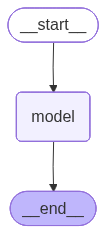

In [80]:
# Basic configuration

from langchain.agents import create_agent
from dotenv import load_dotenv
import os

load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

agent = create_agent(
    model=ChatGroq(model="qwen/qwen3-32b"),
    system_prompt=(
        "You are a helpful web search assistant."
        ## Other configurations like tools, response format, name can be added here as well.
    )
)
agent

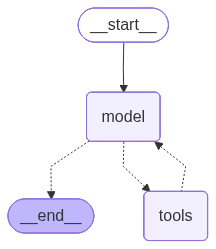

In [84]:
## More configurations can be added as needed, such as tools, response format, etc.'

## Don't confuse, we will deep dive into tools and response formats in the upcoming sections. For now, let's just see how we can add a simple tool to our agent.
from langchain.tools import tool

@tool 
def get_weather(location: str) -> str:
    """A mock function to get weather information for a given location."""
    return f"The weather in {location} is sunny with a high of 25°C."

agent = create_agent(
    name = "AssistantAgent",
    model = ChatGroq(model="qwen/qwen3-32b"),
    system_prompt = "You are a helpful assistant.",
    tools = [get_weather], 
    # response_format = WeatherOutput,
)

agent

In [83]:
## Getting response from the agent

response = agent.invoke({"messages":[{"role": "user", "content": "Hi! My name is Younus, What can i call you?"}]})
print(response["messages"][-1].content)

Hello Younus! I'm Qwen, a language model developed by Alibaba Cloud. How can I assist you today?
